In [1]:
from dl_assignment_2.data.dataSegment import DataSegment, SegmentInfo
from dl_assignment_2.modeling.dataset import CustomDataset
from dl_assignment_2.modeling.model import SimpleRNN
from dl_assignment_2.modeling.trainer import TrainConfig, Trainer
from dl_assignment_2.modeling.evaluation import Evaluator

from numpy import ndarray, array
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import SGD

In [2]:
m1: ndarray = array(range(1, 16)).reshape((3,5))
m2: ndarray = array(range(16, 31)).reshape((3,5))

s1: DataSegment = DataSegment(info=SegmentInfo(m1, 123456, "rest", 1))
s2: DataSegment = DataSegment(info=SegmentInfo(m2, 123456, "rest", 2))

train_ds: CustomDataset   = CustomDataset((s1, s2))
train_dl: DataLoader      = DataLoader(train_ds, batch_size=1, shuffle=True)

In [3]:
m3: ndarray = array(range(2, 17)).reshape((3,5))
m4: ndarray = array(range(17, 32)).reshape((3,5))

s3: DataSegment = DataSegment(info=SegmentInfo(m3, 123456, "rest", 3))
s4: DataSegment = DataSegment(info=SegmentInfo(m4, 123456, "rest", 4))

eval_ds: CustomDataset   = CustomDataset((s3, s4))
eval_dl: DataLoader = DataLoader(eval_ds, batch_size=1, shuffle=True)

In [4]:
rnn: SimpleRNN = SimpleRNN(3, 10, 4)
training_config: TrainConfig = TrainConfig(10, CrossEntropyLoss, SGD, 0.05) # type: ignore

trainer = Trainer(rnn, train_dl, training_config, eval_dl)

In [5]:
trainer.train()

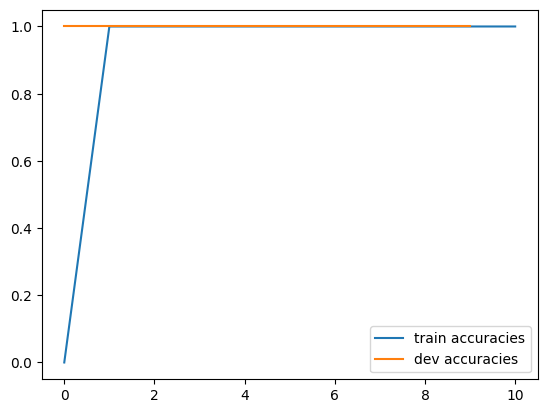

<Axes: >

In [6]:
trainer.plot_accuracy()

In [7]:
from sklearn.metrics import accuracy_score
trainer.evaluate(accuracy_score)

1.0

In [8]:
trainer.train_accuracies

[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]